In [7]:
import pandas as pd
from sqlalchemy import create_engine, text
import redshift_connector
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.plot import plot_plotly
from prophet.plot import add_changepoints_to_plot
from prophet.diagnostics import cross_validation, performance_metrics

In [8]:
# Enter Redshift connection details
conn_args = {
    'host': 'cm-mks-helix-cluster-1.cgv0wa0jntot.us-west-2.redshift.amazonaws.com',
    'database': 'cm_sandbox_4',
    'port': 5439,
    'user': 'tribalvw',
    'password': 'R3$h!ft35263e3f!LxLc'
        }
# Establish connection
conn = redshift_connector.connect(**conn_args)

# Direct read (No S3 staging)
query = "SELECT * FROM tribal_vw.Test2_Advanced_Forecasting"
input_df = pd.read_sql(query, conn) 

# Access the data directly as a Pandas DataFrame
data_df = input_df
data_df

,week_start,total_records_weekly,visits,purchase_intents,quality_arrivals,retailer_leads,orders,brand_spend,pdm_spend,retailer_spend,natural_search_visits,paid_search_visits,direct_visits,paid_social_visits,email_visits,other_channel_visits
0,2022-12-26,1,27150,1774,4599,0,672,0,0,0,21961,1378,3511,0,48,8
1,2023-01-30,7,309406,17961,47882,627,1389,70192,121927,17669,178238,84144,33591,0,909,711
2,2023-03-20,7,355936,17007,54968,835,1208,616438,148999,28174,210177,81379,34174,0,18390,991
3,2023-05-29,7,290721,12586,41345,626,785,99041,87345,16673,177387,56215,35031,0,4897,535
4,2023-07-24,7,331994,15197,47559,929,1366,618460,122028,0,182970,85255,47002,0,8480,903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,2025-12-08,7,188232,14420,50610,1363,665,98008,133415,0,81265,63423,32780,7181,848,313
159,2025-12-22,7,169028,13287,44466,786,368,98008,133415,0,66650,63804,26124,10238,916,158
160,2026-01-19,7,289030,28742,92637,2870,1683,1072860,175668,27575,123509,91702,40713,25666,4792,730
161,2026-01-26,7,298185,27600,86436,2124,1521,700579,216918,27575,128805,81276,48004,32713,2098,640


In [16]:


# Selected Model 0 for ID.3: Simple Model with data as it is and TREATING outliers with custom holidays
data = input.df.copy()
data['week_start'] = pd.to_datetime(data['week_start'])
data = data.iloc[1:-1]
data_df['week_start'] = pd.to_datetime(data_df['week_start'])
data_df = data_df.sort_values(by='week_start', ascending=True)
data_df = data_df.iloc[1:-1]

import pandas as pd
import numpy as np

# List of numeric KPI columns
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Create a copy to preserve original if needed
data_df_cleaned = data_df.copy()

for col in kpis:
    # 1. Calculate IQR bounds
    Q1 = data_df_cleaned[col].quantile(0.25)
    Q3 = data_df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 2 * IQR
    upper_bound = Q3 + 2 * IQR
    
    # 2. Mask values outside bounds with NaN
    # The mask() function replaces values where the condition is True
    data_df_cleaned[col] = data_df_cleaned[col].mask(
        (data_df_cleaned[col] < lower_bound) | (data_df_cleaned[col] > upper_bound), 
        np.nan
    )


# Running the prophet model again on cleaned data
data_df = data_df_cleaned.copy()
# Model 0: Simple Model with data as it is and NOT replacing outliers with NANs or custom holidays

# 1. Data Preparation
data_df['ds'] = pd.to_datetime(data_df['week_start'])
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Apply Log Transformation (log(1+x)) for all KPIs
for kpi in kpis:
    data_df[f'log_{kpi}'] = np.log1p(data_df[kpi])

# 2. Iterative Model Training and Full Timeline Forecasting
final_forecasts = []
mape_scores = {}

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # Initialize Model with UK Holidays
    m = Prophet(seasonality_mode='additive')
    m.add_country_holidays(country_name='UK')
    
    # Fit on all available historical data (up to Jan 19, 2026)
    m.fit(data_df[['ds', f'log_{kpi}']].rename(columns={f'log_{kpi}': 'y'}))
    
    # 3. Create a dataframe covering BOTH History and 3 Months Future
    # 'periods=12' for 3 months (16 weeks) forward from 19 Jan 2026
    full_timeline_df = m.make_future_dataframe(periods=48, freq='W-MON')
    
    # Generate Predictions for the entire period (Dec 2022 to May 2026)
    forecast = m.predict(full_timeline_df)
    
    # 4. Inverse Transformation (e^y - 1) back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    # 5. Calculate MAPE (on historical scale only)
    # Join historical actuals with the corresponding historical predictions
    performance_df = forecast.set_index('ds').join(data_df.set_index('ds')[[kpi]], how='inner')
    mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
    mape_scores[kpi] = mape
    # Formatting the output for Rivery/Export
    forecast = forecast.rename(columns={'ds': 'week_start'})
    data_df['week_start'] = pd.to_datetime(data_df['week_start'])
    # MERGE ACTUALS: Join the original KPI column from ID3_df
    # ID3_df must have 'week_start' and the KPI column (e.g., 'visits')
    forecast_with_actuals = forecast.merge(
        data[['week_start', kpi]], 
        on='week_start', 
        how='left'
    )

   # Store the full forecast for plotting
    # final_forecasts[kpi] = forecast
    
    # Select columns and rename the KPI column (e.g., 'visits') to 'actual'
    forecast_clean = forecast_with_actuals[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', kpi]].copy()
    forecast_clean = forecast_clean.rename(columns={kpi: 'actual'})
    forecast_clean['KPI'] = kpi
    final_forecasts.append(forecast_clean)

   # 5. Final Output DataFrame
final_output_df = pd.concat(final_forecasts, ignore_index=True)
# final_output_df = final_output_df[final_output_df['week_start'] >= '2026-01-19']

# 6. Output MAPE Results
print("\n--- Model Performance (MAPE) ---")
for kpi, score in mape_scores.items():
    print(f"{kpi}: {score:.2f}%")


Processing model for: visits


12:02:09 - cmdstanpy - INFO - Chain [1] start processing
12:02:10 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: quality_arrivals


12:02:10 - cmdstanpy - INFO - Chain [1] start processing
12:02:10 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: purchase_intents


12:02:11 - cmdstanpy - INFO - Chain [1] start processing
12:02:11 - cmdstanpy - INFO - Chain [1] done processing
12:02:11 - cmdstanpy - INFO - Chain [1] start processing


Processing model for: retailer_leads


12:02:11 - cmdstanpy - INFO - Chain [1] done processing



--- Model Performance (MAPE) ---
visits: 4.11%
quality_arrivals: 6.33%
purchase_intents: 7.48%
retailer_leads: 10.25%


In [19]:



# Separate DataFrames for each KPI starting 19 Jan 2026a
all_visits_forecast = final_output_df[final_output_df['KPI'] == 'visits'].copy()
all_purchase_intents_forecast = final_output_df[final_output_df['KPI'] == 'purchase_intents'].copy()
all_quality_arrivals_forecast = final_output_df[final_output_df['KPI'] == 'quality_arrivals'].copy()
all_retailer_leads_forecast = final_output_df[final_output_df['KPI'] == 'retailer_leads'].copy()

# Optional: Remove the 'KPI' column for a clean output for each
all_visits_forecast.drop(columns=['KPI'], inplace=True)
all_purchase_intents_forecast.drop(columns=['KPI'], inplace=True)
all_quality_arrivals_forecast.drop(columns=['KPI'], inplace=True)
all_retailer_leads_forecast.drop(columns=['KPI'], inplace=True)

# Select relevant columns for final output/plotting
all_visits_forecast = all_visits_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_v = all_visits_forecast.copy()
all_purchase_intents_forecast = all_purchase_intents_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_pi = all_purchase_intents_forecast.copy()
all_quality_arrivals_forecast = all_quality_arrivals_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_qa = all_quality_arrivals_forecast.copy()
all_retailer_leads_forecast = all_retailer_leads_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_rl = all_retailer_leads_forecast.copy()

# 1. CLEANING 
forecast_v.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_v.columns
]
# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_v = forecast_v[target_cols].copy()

# 1a. CLEANING 
forecast_pi.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_pi.columns
]
# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_pi = forecast_pi[target_cols].copy()

# 1b. CLEANING 
forecast_qa.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_qa.columns
]

# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_qa = forecast_qa[target_cols].copy()

# 1c. CLEANING 
forecast_rl.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_rl.columns
]

# Select only what you need
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_rl = forecast_rl[target_cols].copy()

import time

# 2. DATABASE OPERATIONS
try:
    conn = redshift_connector.connect(**conn_args)
    conn.autocommit = True 
    cursor = conn.cursor()

    cols_definition = "week_start TIMESTAMP, yhat FLOAT, yhat_lower FLOAT, yhat_upper FLOAT, actual FLOAT"

    # --- STEP 1: DROP, WAIT, AND CREATE TABLES ---
    tables = {
        "af_tribal.m_all_Forecast_Visits": forecast_cleaned_v,
        "af_tribal.m_all_Forecast_PIs": forecast_cleaned_pi,
        "af_tribal.m_all_Forecast_QAs": forecast_cleaned_qa,
        "af_tribal.m_all_Forecast_RLs": forecast_cleaned_rl
    }

    for table_name in tables.keys():
        cursor.execute(f"DROP TABLE IF EXISTS {table_name};")
        time.sleep(3) # Wait for Redshift catalog update
        cursor.execute(f"CREATE TABLE {table_name} ({cols_definition});")
        print(f"Table {table_name} created successfully.")
    
    conn.commit()

    # --- STEP 2: PREPARE AND INSERT DATA INDIVIDUALLY ---
    
    # A. Insert Visits
    print("Inserting data into all_Forecast_Visits...")
    df_v = forecast_cleaned_v.where(pd.notna(forecast_cleaned_v), None)
    df_v['week_start'] = pd.to_datetime(df_v['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_v = [tuple(x) for x in df_v.to_numpy()]
    sql_v = f"INSERT INTO af_tribal.m_all_Forecast_Visits (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_v, tuples_v)
    conn.commit()

    # B. Insert PIs
    print("Inserting data into all_Forecast_PIs...")
    df_pi = forecast_cleaned_pi.where(pd.notna(forecast_cleaned_pi), None)
    df_pi['week_start'] = pd.to_datetime(df_pi['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_pi = [tuple(x) for x in df_pi.to_numpy()]
    sql_pi = f"INSERT INTO af_tribal.m_all_Forecast_PIs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_pi, tuples_pi)
    conn.commit()

    # C. Insert QAs
    print("Inserting data into all_Forecast_QAs...")
    df_qa = forecast_cleaned_qa.where(pd.notna(forecast_cleaned_qa), None)
    df_qa['week_start'] = pd.to_datetime(df_qa['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_qa = [tuple(x) for x in df_qa.to_numpy()]
    sql_qa = f"INSERT INTO af_tribal.m_all_Forecast_QAs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_qa, tuples_qa)
    conn.commit()

    # C. Insert RLs
    print("Inserting data into all_Forecast_RLs...")
    df_rl = forecast_cleaned_rl.where(pd.notna(forecast_cleaned_rl), None)
    df_rl['week_start'] = pd.to_datetime(df_rl['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_rl = [tuple(x) for x in df_rl.to_numpy()]
    sql_rl = f"INSERT INTO af_tribal.m_all_Forecast_RLs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_rl, tuples_rl)
    conn.commit()

    print("Success: All 4 KPI forecasts pushed to Redshift.")

except Exception as e:
    print(f"Error occurred: {e}")
    raise 
finally:
    cursor.close()
    conn.close()
      


Table af_tribal.m_all_Forecast_Visits created successfully.
Table af_tribal.m_all_Forecast_PIs created successfully.
Table af_tribal.m_all_Forecast_QAs created successfully.
Table af_tribal.m_all_Forecast_RLs created successfully.
Inserting data into all_Forecast_Visits...
Inserting data into all_Forecast_PIs...
Inserting data into all_Forecast_QAs...
Inserting data into all_Forecast_RLs...
Success: All 4 KPI forecasts pushed to Redshift.


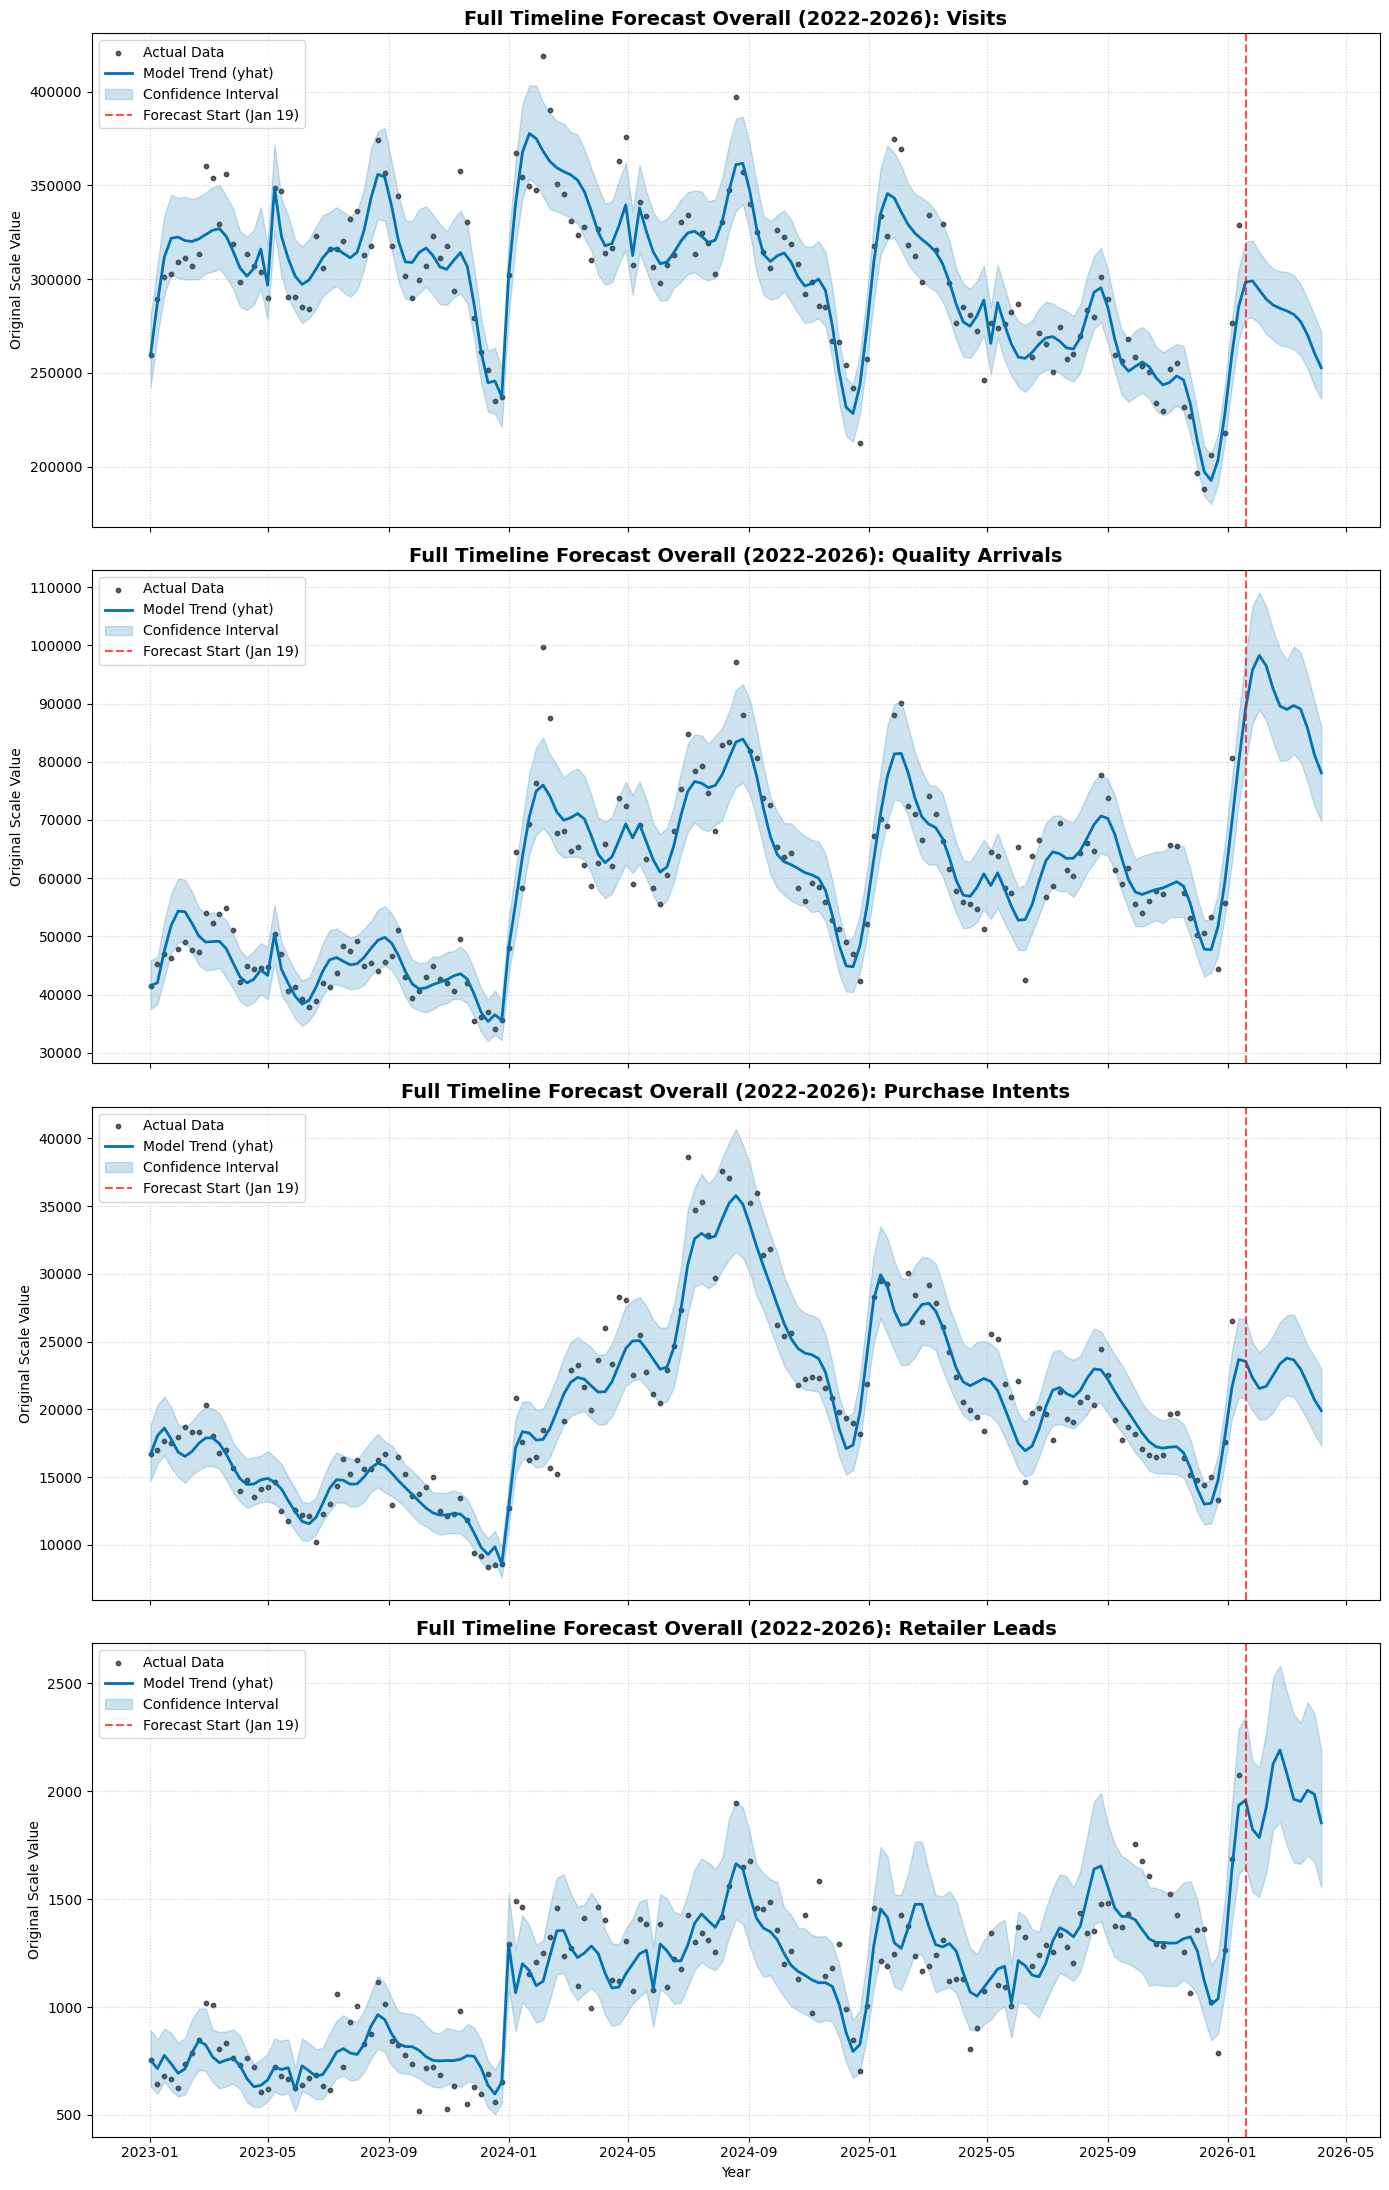

In [11]:
# 7. Visualization: Full Timeline (Actuals vs Predicted)
fig, axes = plt.subplots(4, 1, figsize=(14, 22), sharex=True)

for i, kpi in enumerate(kpis):
    ax = axes[i]
    forecast_df = final_forecasts[kpi]
    
    # Plot Historical Actuals as black dots
    ax.scatter(data_df['ds'], data_df[kpi], color='black', label='Actual Data', s=10, alpha=0.6)
    
    # Plot Continuous Model Trend Line (History + Future)
    ax.plot(forecast_df['ds'], forecast_df['yhat'], color='#0072B2', label='Model Trend (yhat)', linewidth=2)
    
    # Plot Confidence Intervals (Shaded Area)
    ax.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'], 
                    color='#0072B2', alpha=0.2, label='Confidence Interval')
    
    # Add a vertical line to mark the start of the 2026 Forecast
    ax.axvline(pd.to_datetime('2026-01-19'), color='red', linestyle='--', alpha=0.7, label='Forecast Start (Jan 19)')
    
    # Formatting
    ax.set_title(f'Full Timeline Forecast Overall (2022-2026): {kpi.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Original Scale Value')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')

plt.xlabel('Year')
plt.tight_layout()
plt.show()

In [13]:
    
    # Formatting the output for Rivery/Export
forecast = forecast.rename(columns={'ds': 'week_start'})
forecast_clean = forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_clean['KPI'] = kpi
final_forecasts.append(forecast_clean)

   # 5. Final Output DataFrame
final_output_df = pd.concat(final_forecasts, ignore_index=True)
# final_output_df = final_output_df[final_output_df['week_start'] >= '2026-01-19']


AttributeError: 'dict' object has no attribute 'append'

In [19]:



# Enter Redshift connection details
conn_args = {
    'host': 'cm-mks-helix-cluster-1.cgv0wa0jntot.us-west-2.redshift.amazonaws.com',
    'database': 'cm_sandbox_4',
    'port': 5439,
    'user': 'tribalvw',
    'password': 'R3$h!ft35263e3f!LxLc'
        }
# Establish connection
conn = redshift_connector.connect(**conn_args)

# Direct read (No S3 staging)
query = "SELECT * FROM tribal_vw.Test2_Advanced_Forecasting"
input_df = pd.read_sql(query, conn) 

# Access the data directly as a Pandas DataFrame
data_df = input_df

# Selected Model 0 for ID.3: Simple Model with data as it is and TREATING outliers with custom holidays

data_df['week_start'] = pd.to_datetime(data_df['week_start'])
data_df = data_df.sort_values(by='week_start', ascending=True)
data_df = data_df.iloc[1:-1]

import pandas as pd
import numpy as np

# List of numeric KPI columns
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Create a copy to preserve original if needed
data_df_cleaned = data_df.copy()

for col in kpis:
    # 1. Calculate IQR bounds
    Q1 = data_df_cleaned[col].quantile(0.25)
    Q3 = data_df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 2 * IQR
    upper_bound = Q3 + 2 * IQR
    
#    # 2. Mask values outside bounds with NaN
#    # The mask() function replaces values where the condition is True
    data_df_cleaned[col] = data_df_cleaned[col].mask(
        (data_df_cleaned[col] < lower_bound) | (data_df_cleaned[col] > upper_bound), 
        np.nan
    )


# Running the prophet model again on cleaned data
data_df = data_df_cleaned.copy()
# Model 0: Simple Model with data as it is and NOT replacing outliers with NANs or custom holidays

# 1. Data Preparation
data_df['ds'] = pd.to_datetime(data_df['week_start'])
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Apply Log Transformation (log(1+x)) for all KPIs
for kpi in kpis:
    data_df[f'log_{kpi}'] = np.log1p(data_df[kpi])

# 2. Iterative Model Training and Full Timeline Forecasting
final_forecasts = []
mape_scores = {}

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # Initialize Model with UK Holidays
    m = Prophet(seasonality_mode='additive')
    m.add_country_holidays(country_name='UK')
    
    # Fit on all available historical data (up to Jan 19, 2026)
    m.fit(data_df[['ds', f'log_{kpi}']].rename(columns={f'log_{kpi}': 'y'}))
    
    # 3. Create a dataframe covering BOTH History and 3 Months Future
    # 'periods=12' for 3 months (16 weeks) forward from 19 Jan 2026
    full_timeline_df = m.make_future_dataframe(periods=12, freq='W-MON')
    
    # Generate Predictions for the entire period (Dec 2022 to May 2026)
    forecast = m.predict(full_timeline_df)
    
    # 4. Inverse Transformation (e^y - 1) back to original scale
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.expm1(forecast[col])
    
    # 5. Calculate MAPE (on historical scale only)
    # Join historical actuals with the corresponding historical predictions
    performance_df = forecast.set_index('ds').join(data_df.set_index('ds')[[kpi]], how='inner')
    mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi])) * 100
    mape_scores[kpi] = mape
    
    # Store the full forecast for plotting
    # final_forecasts[kpi] = forecast
    
    # Formatting the output for Rivery/Export
    forecast = forecast.rename(columns={'ds': 'week_start'})
    forecast_clean = forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    forecast_clean['KPI'] = kpi
    final_forecasts.append(forecast_clean)

   # 5. Final Output DataFrame
final_output_df = pd.concat(final_forecasts, ignore_index=True)
# final_output_df = final_output_df[final_output_df['week_start'] >= '2026-01-19']


# 6. Output MAPE Results
print("\n--- Model Performance (MAPE) ---")
for kpi, score in mape_scores.items():
    print(f"{kpi}: {score:.2f}%")

# Print verification for Rivery logs
print("--- 12-WEEK FORECAST (Starting 19 Jan 2026) ---")
print(final_output_df.head(15))


# Separate DataFrames for each KPI starting 19 Jan 2026
All_visits_forecast = final_output_df[final_output_df['KPI'] == 'visits'].copy()
All_purchase_intents_forecast = final_output_df[final_output_df['KPI'] == 'purchase_intents'].copy()
All_quality_arrivals_forecast = final_output_df[final_output_df['KPI'] == 'quality_arrivals'].copy()
All_retailer_leads_forecast = final_output_df[final_output_df['KPI'] == 'retailer_leads'].copy()

Processing model for: visits


13:48:29 - cmdstanpy - INFO - Chain [1] start processing
13:48:29 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: quality_arrivals


13:48:30 - cmdstanpy - INFO - Chain [1] start processing
13:48:30 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: purchase_intents


13:48:31 - cmdstanpy - INFO - Chain [1] start processing
13:48:31 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: retailer_leads


13:48:32 - cmdstanpy - INFO - Chain [1] start processing
13:48:32 - cmdstanpy - INFO - Chain [1] done processing



--- Model Performance (MAPE) ---
visits: 4.08%
quality_arrivals: 6.33%
purchase_intents: 7.52%
retailer_leads: 10.22%
--- 12-WEEK FORECAST (Starting 19 Jan 2026) ---
   week_start           yhat     yhat_lower     yhat_upper     KPI
0  2023-01-02  259559.057304  243404.636578  279228.516542  visits
1  2023-01-09  287787.698662  269669.407933  308216.002851  visits
2  2023-01-16  311423.253789  290024.214336  333140.661051  visits
3  2023-01-23  321206.297446  301142.953203  345634.570193  visits
4  2023-01-30  322123.646404  300771.298412  345523.241607  visits
5  2023-02-06  320865.808186  299829.040724  344703.301170  visits
6  2023-02-13  320795.895021  301569.173505  345637.512852  visits
7  2023-02-20  322152.108160  300359.791339  344948.355080  visits
8  2023-02-27  324296.725675  302349.773436  346399.621249  visits
9  2023-03-06  326588.124870  305343.503689  348814.902174  visits
10 2023-03-13  327620.540886  305854.074791  349265.501838  visits
11 2023-03-20  323288.469478 